<!-- TAG: week-6-policy-gradient-methods -->
# Week 6: Policy Gradient Methods

**MSDS 684 — Reinforcement Learning · Regis University**

**Textbook**: Sutton & Barto (2018), *Reinforcement Learning: An Introduction*, 2nd ed., Chapter 13
**Secondary**: Williams, R.J. (1992). "Simple Statistical Gradient-Following Algorithms for Connectionist Reinforcement Learning." *Machine Learning*, 8, 229–256.
**Supplementary**: Sutton, R.S., McAllester, D., Singh, S., & Mansour, Y. (2000). "Policy Gradient Methods for Reinforcement Learning with Function Approximation." *NeurIPS*.

---

### Learning Objectives
By the end of this lecture you will be able to:

1. Explain why some problems require stochastic policies that value-based methods can't produce.
2. Trace the computation inside softmax and Gaussian policy parameterizations.
3. Derive and compute the policy gradient for a simple problem by hand.
4. Demonstrate why REINFORCE has high variance and how baselines fix it.
5. Explain how Actor-Critic methods trade bias for lower variance by bootstrapping.
6. Place policy gradient methods in the landscape of RL algorithms we've studied.

---

In [ ]:
# TAG: load-libraries
%matplotlib inline
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

print("NumPy version: ", np.__version__)
print("PyTorch version:", torch.__version__)

<!-- TAG: 1-the-case-for-direct-policy-optimization -->
---
## 1  The Case for Direct Policy Optimization

Here's the headline: everything we've built over the past five weeks answers the question *what is each action worth?* and then picks the best one. This week we skip the middleman. We learn the policy directly.

Why? Two reasons, and both are situations where the value-based playbook breaks down. We'll prove each one with code before we move on.

<!-- TAG: 1a-stochastic-policies -->
### 1.1  Some Problems Require Randomization

Q-learning gives you a deterministic policy: one action per state, no exceptions. In many environments that's fine. In some it's fatal. Consider the simplest possible example of the second kind.

In [ ]:
# TAG: demo-rps
# Rock-Paper-Scissors against an adaptive opponent.
# The optimal strategy is to randomize uniformly — exactly the thing argmax can't do.

payoff = np.array([[ 0, -1,  1],    # Rock    vs {R, P, S}
                   [ 1,  0, -1],    # Paper   vs {R, P, S}
                   [-1,  1,  0]])   # Scissors vs {R, P, S}
actions = ['Rock', 'Paper', 'Scissors']

# Suppose Q-learning converged to these values from self-play
Q = np.array([0.12, 0.08, -0.03])
det_action = np.argmax(Q)

print("Scenario: Rock-Paper-Scissors against an adaptive opponent")
print("=" * 60)
print(f"\nQ-values from training:  Q(Rock)={Q[0]:.2f}  Q(Paper)={Q[1]:.2f}  Q(Scissors)={Q[2]:.2f}")
print(f"argmax policy:           Always play {actions[det_action]}")

# Adaptive opponent: tracks our action frequencies, counters the most common
def simulate_match(our_policy, n_games=5000, seed=42):
    rng = np.random.RandomState(seed)
    history = []
    total = 0
    for i in range(n_games):
        our_action = rng.choice(3, p=our_policy)
        history.append(our_action)
        if i < 20:
            opp_action = rng.choice(3)
        else:
            counts = np.bincount(history, minlength=3)
            opp_action = (np.argmax(counts) + 1) % 3
        total += payoff[our_action, opp_action]
    return total / n_games

# Deterministic policy: always Rock
det_policy = np.array([1.0, 0.0, 0.0])
det_result = simulate_match(det_policy)
print(f"\nDeterministic (always {actions[det_action]}) vs. adaptive opponent:")
print(f"  Average reward per game: {det_result:+.3f}")
print(f"  Translation: we lose almost every game.\n")

# Stochastic policy: uniform random
stoch_policy = np.array([1/3, 1/3, 1/3])
stoch_result = simulate_match(stoch_policy)
print(f"Stochastic (1/3, 1/3, 1/3) vs. adaptive opponent:")
print(f"  Average reward per game: {stoch_result:+.3f}")
print(f"  Translation: opponent can't find a pattern to exploit.\n")

# Slightly biased — still much better than deterministic
biased_policy = np.array([0.5, 0.3, 0.2])
biased_result = simulate_match(biased_policy)
print(f"Slightly biased (0.5, 0.3, 0.2) vs. adaptive opponent:")
print(f"  Average reward per game: {biased_result:+.3f}")
print(f"  Translation: exploitable, but less so than deterministic.\n")

print("argmax gives you exactly one action per state.")
print("Some games punish predictability. You NEED a distribution over actions.")
print("Policy gradients produce distributions naturally. Q-learning's argmax can't.")

<!-- TAG: obs-rps -->
> **The takeaway isn't exotic.** Rock-Paper-Scissors is a toy, but the principle scales. Any multi-agent setting — negotiation, bidding, security patrols — can have this property: if your opponent can predict your action, they can exploit you. Stochastic policies are the defense. Value-based methods with argmax are constitutionally incapable of producing them.

<!-- TAG: 1b-continuous-actions -->
### 1.2  Continuous Actions Make argmax Impossible

The second problem is more common and more fundamental. Robotics, autonomous driving, climate control — any domain where the action is a real number (or a vector of real numbers). Q-learning needs $\arg\max_a Q(s, a)$, and when $a \in \mathbb{R}$, that's an optimization problem you'd have to solve *inside every step*. Policy gradients sidestep it entirely.

In [ ]:
# TAG: demo-continuous-target
# Task: pick a temperature setting (a real number). Reward = closeness to unknown ideal.
# Q-learning can't argmax over ℝ. Policy gradients can learn a Gaussian and sample.

ideal_temp = 21.7  # unknown to the agent

print("Scenario: Continuous action — pick a temperature setting")
print("=" * 58)
print(f"Ideal temperature: {ideal_temp} (unknown to the agent)\n")

print("Value-based approach:")
print("  Needs argmax_a Q(s, a) where a ∈ ℝ")
print("  That's optimization over an infinite set, every step. Impractical.\n")

print("Policy gradient approach: learn μ for a Gaussian π(a) = N(μ, σ²)")
print("  Sample actions, observe rewards, nudge μ toward what works.\n")

mu = 15.0       # bad initial guess
sigma = 3.0     # wide uncertainty
lr = 0.5
batch_size = 30

print(f"{'Step':>4}  {'μ':>7}  {'Best sample':>12}  {'Reward':>8}")
print("-" * 42)

rng = np.random.RandomState(7)
for step in range(12):
    # Sample a batch of actions from current Gaussian policy
    batch = rng.normal(mu, sigma, size=batch_size)
    rewards = -((batch - ideal_temp) ** 2)

    # Policy gradient: ∇_μ log N(a; μ, σ²) = (a - μ)/σ²
    # With baseline (mean reward) for variance reduction
    baseline = rewards.mean()
    advantages = rewards - baseline
    grad_mu = np.mean(((batch - mu) / sigma**2) * advantages)

    best_idx = np.argmax(rewards)
    print(f"{step+1:4d}  {mu:7.2f}  {batch[best_idx]:12.2f}  {rewards[best_idx]:8.2f}")

    mu += lr * grad_mu
    sigma = max(0.5, sigma * 0.95)  # slowly reduce exploration

print(f"\nFinal μ = {mu:.2f}  (target was {ideal_temp})")
print("\nNo table. No argmax. Just a parameterized distribution and gradient ascent.")

<!-- TAG: obs-continuous -->
> **Two problems, one answer.** Stochastic policies handle games where randomization is optimal. Parameterized distributions handle continuous action spaces where argmax is impossible. Policy gradient methods give you both because they work directly with probability distributions over actions — not with value estimates that need an argmax to become decisions.

<!-- TAG: 2-whats-inside-a-policy -->
---
## 2  What's Inside a Policy

Before we optimize a policy, we need to understand how one is *built*. In value-based methods, we stored Q(s, a) and extracted a policy indirectly via argmax. Policy gradient methods skip the middleman — they parameterize the policy directly as a function π(a|s; θ), where the parameter vector (θ) is what the agent learns.

Two parameterizations matter for this course: **softmax** for discrete actions, **Gaussian** for continuous. Both do the same fundamental job: they convert a vector of raw numbers (the learnable parameters θ) into a valid probability distribution over actions. And both are differentiable — which is the whole game, because without a gradient we can't do gradient ascent on expected return.

### 2.1  Softmax: Turning Numbers into Probabilities

In a softmax policy, the parameter vector (θ) contains one weight per action (or, when states are involved, a weight for each state-action feature). Higher weight means higher probability of selecting that action. The softmax function handles the conversion:

$$\pi(a \mid s;\, \boldsymbol{\theta}) = \frac{e^{\theta_a}}{\sum_{b} e^{\theta_b}}$$

We're about to trace this computation step by step on three actions. The goal is to see exactly how raw weights become probabilities, and what happens to that distribution when we nudge a single weight — because that nudge is exactly what the policy gradient does during learning.

In [ ]:
# TAG: demo-softmax-trace
# Trace the softmax computation by hand. No neural network — just raw weights.
# One state, three actions.

theta = np.array([1.0, 2.0, 0.5])

# Step 1: Exponentiate
exp_theta = np.exp(theta)
print("Step 1 — Exponentiate θ (make everything positive):")
print(f"  θ         = {theta}")
print(f"  exp(θ)    = [{exp_theta[0]:.4f}, {exp_theta[1]:.4f}, {exp_theta[2]:.4f}]")

# Step 2: Normalize
probs = exp_theta / exp_theta.sum()
print(f"\nStep 2 — Normalize (divide by sum = {exp_theta.sum():.4f}):")
print(f"  π(a|s;θ)  = [{probs[0]:.4f}, {probs[1]:.4f}, {probs[2]:.4f}]")
print(f"  Highest weight → highest probability. Makes sense.")

# Step 3: Sample
rng = np.random.RandomState(0)
action = rng.choice(3, p=probs)
print(f"\nStep 3 — Sample an action: drew action {action}")

# Step 4: Log probability
log_prob = np.log(probs[action])
print(f"\nStep 4 — log π(a={action}|s;θ) = log({probs[action]:.4f}) = {log_prob:.4f}")
print("  (This is what the policy gradient multiplies by the return.)")

# Now watch what happens when we change one weight
print("\n" + "=" * 60)
print("What if we increase θ[1] by 0.5?\n")
theta_new = theta.copy()
theta_new[1] += 0.5
probs_new = np.exp(theta_new) / np.exp(theta_new).sum()

print(f"  Old θ = [{theta[0]:.1f}, {theta[1]:.1f}, {theta[2]:.1f}]  →  π = [{probs[0]:.4f}, {probs[1]:.4f}, {probs[2]:.4f}]")
print(f"  New θ = [{theta_new[0]:.1f}, {theta_new[1]:.1f}, {theta_new[2]:.1f}]  →  π = [{probs_new[0]:.4f}, {probs_new[1]:.4f}, {probs_new[2]:.4f}]")
print(f"\n  θ[0] and θ[2] did NOT change — still {theta[0]:.1f} and {theta[2]:.1f}.")
print(f"  But watch what happened to their probabilities:\n")
print(f"  Action 0 prob: {probs[0]:.4f} → {probs_new[0]:.4f}  (down — weight unchanged!)")
print(f"  Action 1 prob: {probs[1]:.4f} → {probs_new[1]:.4f}  (up — its weight increased)")
print(f"  Action 2 prob: {probs[2]:.4f} → {probs_new[2]:.4f}  (down — weight unchanged!)")
print("\n  That's normalization at work. Softmax is a zero-sum game:")
print("  boosting one action's weight steals probability from every other action,")
print("  even though their weights didn't move. One knob turns, all dials shift.")

<!-- TAG: viz-softmax-transform -->
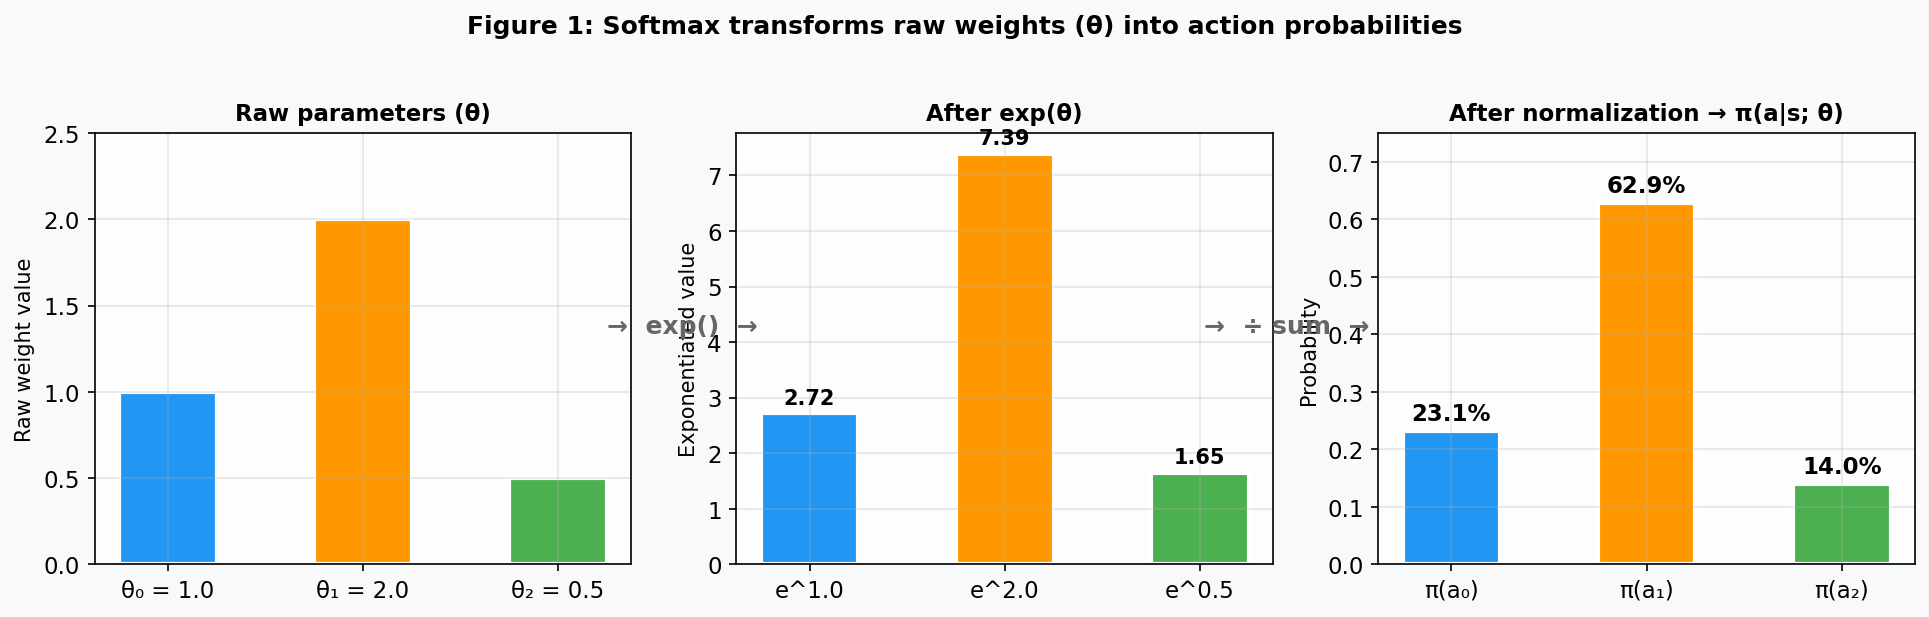

<!-- TAG: obs-softmax -->
> **The softmax guarantee**: every action always has nonzero probability. That's structurally different from ε-greedy, where exploration is a bolted-on coin flip. Here, the exploration *is* the policy. As weights diverge during training, the distribution sharpens toward the best action — but it never actually reaches zero for the others. Convergence, not a cliff.

<!-- TAG: 2b-gaussian-policy -->
### 2.2  Gaussian: A Distribution over Real Numbers

In [ ]:
# TAG: demo-gaussian-trace
# Same idea for continuous actions: trace the Gaussian policy by hand.

mu = 3.0       # current best guess for the ideal action
sigma = 1.5    # how uncertain we are

print("Gaussian Policy: π(a|s) = Normal(μ, σ²)")
print(f"  μ = {mu}  (center)      σ = {sigma}  (spread)\n")

# Sample some actions and compute their log probabilities
rng = np.random.RandomState(42)
samples = rng.normal(mu, sigma, size=5)
print("Five sampled actions:")
print(f"  {'Action':>8}  {'|a - μ|':>8}  {'log π(a)':>9}")
print("  " + "-" * 30)
for a in samples:
    log_p = -0.5 * np.log(2 * np.pi * sigma**2) - (a - mu)**2 / (2 * sigma**2)
    print(f"  {a:+8.3f}  {abs(a - mu):8.3f}  {log_p:9.3f}")

print(f"\n  Closer to μ → higher log probability. That's the gradient signal.\n")

# Effect of changing μ
print("=" * 60)
print("Effect of shifting μ (keeping σ = 1.5):\n")
print(f"  {'μ':>5}  {'π(a=2)':>8}  {'π(a=3)':>8}  {'π(a=4)':>8}  {'Peak at':>8}")
print("  " + "-" * 42)
for mu_test in [1.0, 3.0, 5.0]:
    vals = []
    for a in [2.0, 3.0, 4.0]:
        p = np.exp(-0.5 * np.log(2 * np.pi * sigma**2) - (a - mu_test)**2 / (2 * sigma**2))
        vals.append(p)
    print(f"  {mu_test:5.1f}  {vals[0]:8.4f}  {vals[1]:8.4f}  {vals[2]:8.4f}  {mu_test:8.1f}")
print("\n  Shifting μ slides the entire distribution. The peak follows.\n")

# Effect of changing σ
print("Effect of changing σ (keeping μ = 3.0):\n")
print(f"  {'σ':>5}  {'π(a=2)':>8}  {'π(a=3)':>8}  {'π(a=4)':>8}  {'Behavior':>12}")
print("  " + "-" * 48)
for sigma_test, desc in [(0.5, 'Confident'), (1.5, 'Moderate'), (3.0, 'Exploring')]:
    vals = []
    for a in [2.0, 3.0, 4.0]:
        p = np.exp(-0.5 * np.log(2 * np.pi * sigma_test**2) - (a - 3.0)**2 / (2 * sigma_test**2))
        vals.append(p)
    print(f"  {sigma_test:5.1f}  {vals[0]:8.4f}  {vals[1]:8.4f}  {vals[2]:8.4f}  {desc:>12}")

print("\n  Small σ → sharp peak (confident). Large σ → flat (exploring).")
print("  The agent can learn BOTH what to do (μ) and how sure it is (σ).")

<!-- TAG: viz-gaussian-policy -->
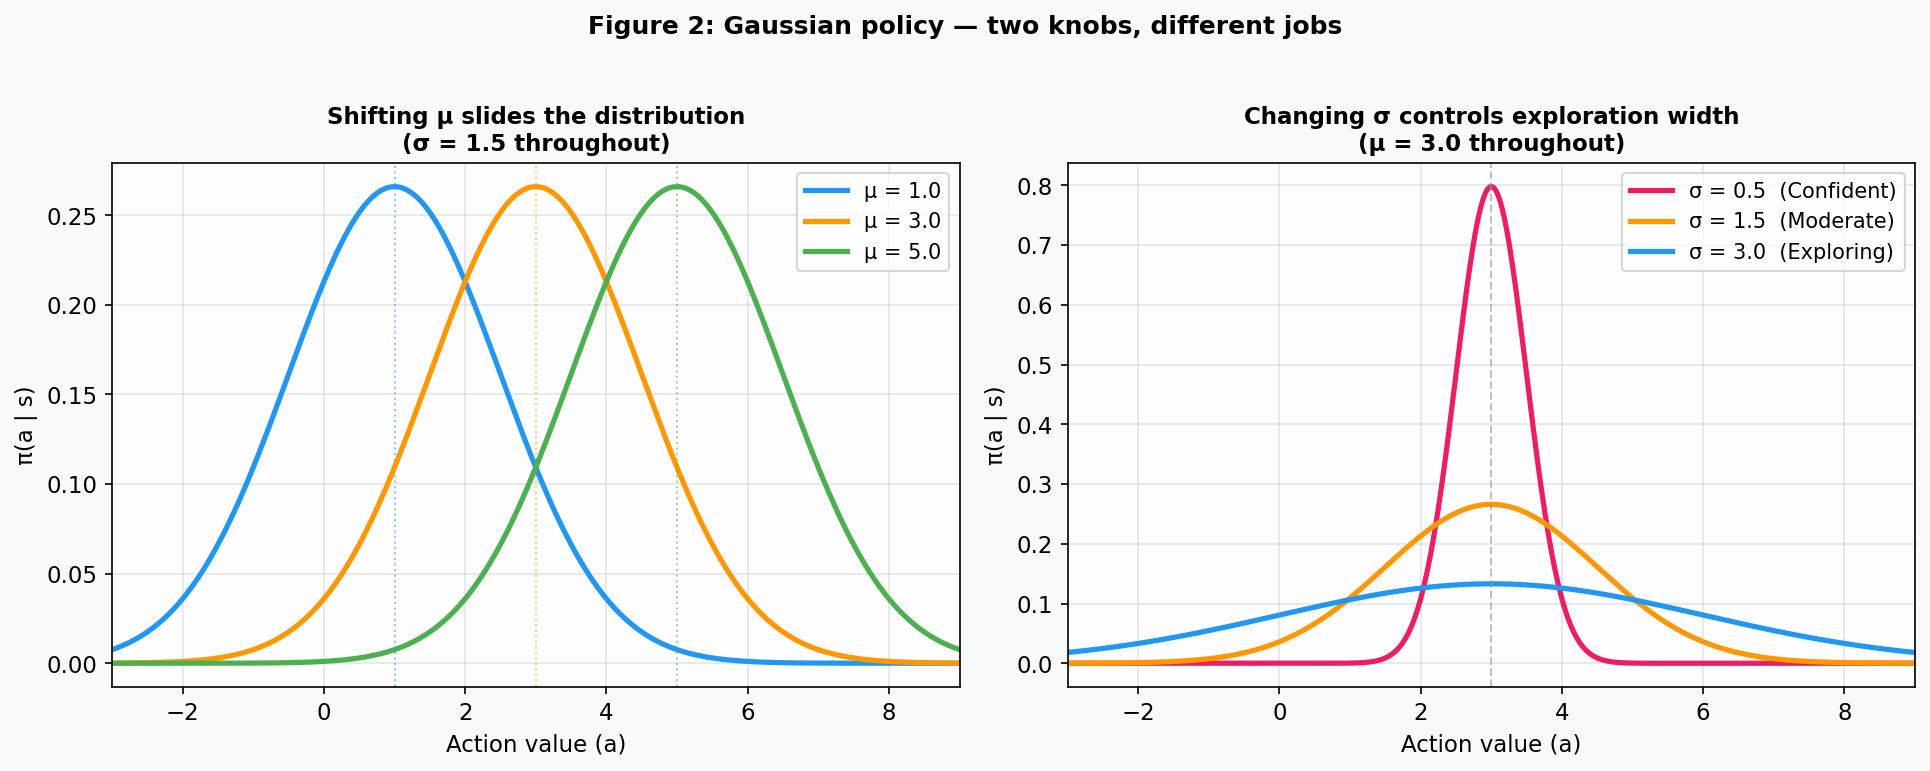

<!-- TAG: obs-gaussian -->
> **Two knobs, different jobs.** μ controls *where* the policy is centered — the agent's best guess. σ controls *how much it explores* — how willing it is to try actions far from that guess. In practice σ often starts large and shrinks as the agent gains confidence. Some algorithms learn σ alongside μ; others decay it on a schedule. Either way, it's more elegant than ε-greedy's coin flip.

<!-- TAG: 3-policy-gradient-theorem -->
---
## 3  The Policy Gradient Theorem

We have a parameterized policy π(a|s; θ) — either softmax (Section 2.1) or Gaussian (Section 2.2). The parameter vector (θ) is what we get to tune. The question is: which direction should we move θ to make the agent perform better?

To answer that, we need a single number that says "how good is the current policy?" That number is the **objective function** (J(θ)):

$$J(\theta) = \mathbb{E}_{\pi_\theta}\left[G_0\right]$$

In words: the objective (J(θ)) is the expected return (G₀) — the total discounted reward from the start of an episode — averaged over all possible episodes that the current policy would generate. Higher J means the policy collects more reward on average. Our job is to find the θ that makes J as large as possible.

The natural tool is gradient ascent: compute the gradient of the objective with respect to the parameters (∇_θ J(θ)) and step uphill. But here's the catch — the objective (J(θ)) is an expectation over entire trajectories, and the trajectory distribution depends on θ in a tangled way. The parameters (θ) affect which actions we take, which affects which states we visit, which affects which actions we take next. The dependencies thread through the entire episode. You can't just differentiate through all of that... or can you?

The **Policy Gradient Theorem** (Sutton et al., 2000) cuts through the tangle with a result that's almost too clean:

$$\nabla_\theta J(\theta) = \mathbb{E}\left[\sum_t \nabla_\theta \log \pi(A_t | S_t; \theta) \cdot G_t\right]$$

where the return (G_t) is the discounted sum of rewards from time step t onward: G_t = R_{t+1} + γR_{t+2} + γ²R_{t+3} + ⋯

In English: the gradient of the expected return equals the expected value of the gradient of the log-probability of each action, weighted by the return that followed it. Good actions (high G_t) get their log-probabilities pushed up — making them more likely. Bad actions (low G_t) get pushed down. The size of the push is proportional to how good or bad the outcome was.

Notice what *doesn't* appear in this equation: the transition dynamics of the environment. We don't need to know how the environment works — only how our own policy works. That's what makes this practical.

### 3.1  The Score Function Trick

The mathematical move that makes the theorem work is the **log-derivative trick** (also called the score function trick):

$$\nabla_\theta \log \pi(a|s;\theta) = \frac{\nabla_\theta \pi(a|s;\theta)}{\pi(a|s;\theta)}$$

This identity converts a gradient of a probability (hard to work with) into a gradient of a log-probability (easy to estimate from samples, because we already compute log π when we sample actions). Let's verify it numerically — no trust required.

In [ ]:
# TAG: demo-score-function
# Verify the score function trick: ∇ log π = ∇π / π
# Using our softmax policy from Section 2.

theta = np.array([1.0, 2.0, 0.5])
action = 1  # analyze action 1

def softmax(t):
    e = np.exp(t - t.max())
    return e / e.sum()

probs = softmax(theta)
log_prob = np.log(probs[action])

print("Verifying the score function trick for softmax")
print("=" * 55)
print(f"θ = {theta}")
print(f"π(a=1|θ) = {probs[action]:.6f}")
print(f"log π(a=1|θ) = {log_prob:.6f}\n")

# Method 1: Numerical gradient of log π (finite differences)
eps = 1e-5
grad_log_numerical = np.zeros(3)
for i in range(3):
    theta_plus = theta.copy();  theta_plus[i] += eps
    theta_minus = theta.copy(); theta_minus[i] -= eps
    grad_log_numerical[i] = (np.log(softmax(theta_plus)[action]) -
                              np.log(softmax(theta_minus)[action])) / (2 * eps)

print("Method 1 — Numerical ∇_θ log π:")
print(f"  {grad_log_numerical.round(6)}\n")

# Method 2: Analytical formula for softmax
# ∇_{θ_i} log π(a|θ) = 1(i=a) - π(i)
grad_log_analytical = -probs.copy()
grad_log_analytical[action] += 1.0

print("Method 2 — Analytical  (𝟙(i=a) - π(i)):")
print(f"  {grad_log_analytical.round(6)}\n")

print(f"Match? Max difference: {np.max(np.abs(grad_log_numerical - grad_log_analytical)):.2e}\n")

# Method 3: Verify ∇log π = ∇π / π
grad_pi_numerical = np.zeros(3)
for i in range(3):
    theta_plus = theta.copy();  theta_plus[i] += eps
    theta_minus = theta.copy(); theta_minus[i] -= eps
    grad_pi_numerical[i] = (softmax(theta_plus)[action] -
                             softmax(theta_minus)[action]) / (2 * eps)

ratio = grad_pi_numerical / probs[action]

print("Method 3 — ∇π / π  (the log-derivative identity):")
print(f"  ∇π(a=1)    = {grad_pi_numerical.round(6)}")
print(f"  π(a=1)     = {probs[action]:.6f}")
print(f"  ∇π / π     = {ratio.round(6)}")
print(f"  ∇ log π    = {grad_log_analytical.round(6)}")
print(f"\n  Identical. The trick works.\n")

print("Notice: the gradient for action 1 (the one we took) is POSITIVE.")
print("The gradient for actions 0 and 2 is NEGATIVE.")
print("This is the score function saying: 'to increase the probability of")
print("action 1, push θ₁ up and push θ₀, θ₂ down.' The policy gradient")
print("then SCALES this direction by the return — good or bad.")

<!-- TAG: viz-score-function -->
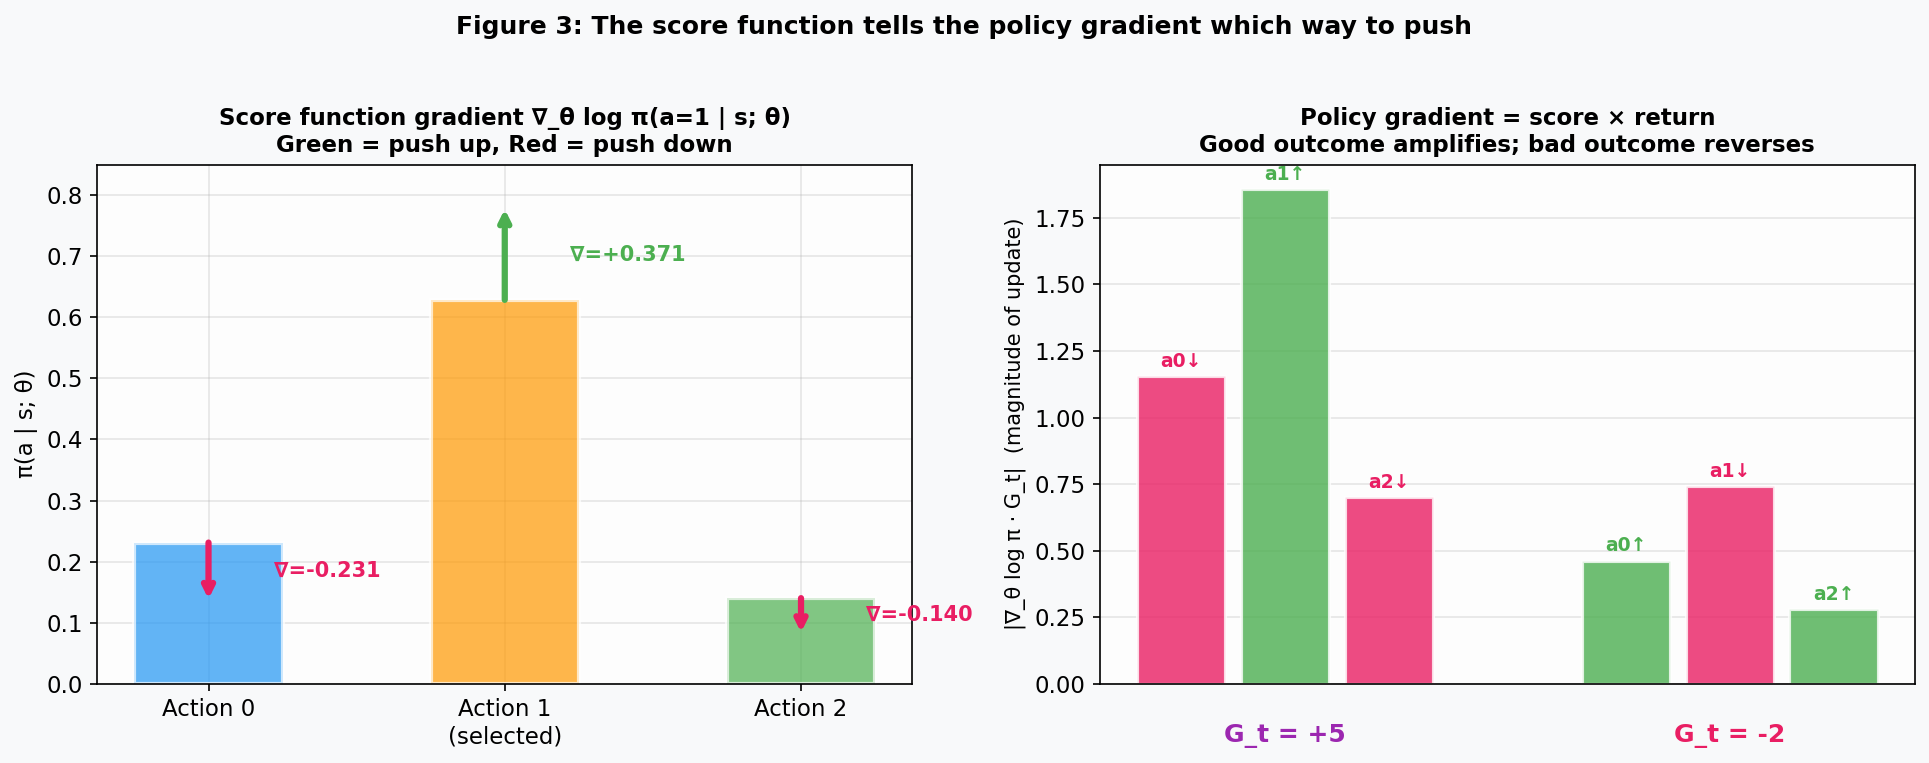

<!-- TAG: obs-score -->
> **Why the log matters.** Without the log, we'd need ∇π, which involves differentiating a normalized probability. The log-derivative trick converts it to ∇log π, which is tractable for any differentiable policy. And the identity ∇log π = ∇π/π has a useful side effect: the gradient is *amplified for rare actions*. If π(a) is small, dividing by it makes the gradient larger. Unusual actions carry more information per sample. That's importance weighting baked in for free.

<!-- TAG: 3b-bandit-demo -->
### 3.2  REINFORCE — The Algorithm

We have the pieces: a differentiable policy π(a|s;θ), the score function ∇log π, and a return G to tell us how good the outcome was. **REINFORCE** (Williams, 1992) is the algorithm that puts them together. The name is a somewhat forced acronym — "REward Increment = Nonnegative Factor × Offset Reinforcement × Characteristic Eligibility" — but nobody uses the expansion. What matters is the procedure:

1. Run the agent through a complete episode using the current policy.
2. For each timestep t, compute the return G_t (the discounted sum of rewards from t onward).
3. For each timestep t, compute the score function ∇_θ log π(a_t | s_t; θ).
4. Update the parameters: θ ← θ + α · G_t · ∇_θ log π(a_t | s_t; θ).

That's it. The return tells us *how good* this action turned out. The score function tells us *which direction in parameter space* would make this action more likely. Multiplying them gives a gradient estimate that, in expectation, points toward higher total reward. Repeat across many episodes and the policy improves.

Let's watch it work on the simplest possible problem: a three-armed bandit. One state, three actions, different expected rewards. Every update visible.

In [ ]:
# TAG: demo-bandit-pg
# 3-armed bandit. True expected rewards: [+1, -1, +5].
# The agent should learn to favor action 2.

true_rewards = np.array([1.0, -1.0, 5.0])
theta = np.zeros(3)  # uniform initial policy
alpha = 0.1
n_steps = 25

rng = np.random.RandomState(42)

# Run REINFORCE and record history
pi_history = np.zeros((n_steps + 1, 3))
pi_history[0] = softmax(theta)
actions_taken = []
rewards_seen = []

for step in range(n_steps):
    probs = softmax(theta)
    action = rng.choice(3, p=probs)
    reward = true_rewards[action] + rng.randn() * 0.5

    actions_taken.append(action)
    rewards_seen.append(reward)

    # REINFORCE update: θ ← θ + α * ∇log π(a|θ) * R
    score = -probs.copy()
    score[action] += 1.0
    theta += alpha * score * reward

    pi_history[step + 1] = softmax(theta)

# Show a few key snapshots instead of the full table
import pandas as pd
snapshots = [0, 1, 2, 5, 10, 15, 24]
rows = []
for i in snapshots:
    p = pi_history[i]
    row = {'Step': i, 'π(a₀)': f'{p[0]:.3f}', 'π(a₁)': f'{p[1]:.3f}',
           'π(a₂)': f'{p[2]:.3f}'}
    if i > 0:
        row['Action'] = actions_taken[i-1]
        row['Reward'] = f'{rewards_seen[i-1]:+.2f}'
    else:
        row['Action'] = '—'
        row['Reward'] = '—'
    rows.append(row)

# Final
p = pi_history[-1]
rows.append({'Step': n_steps, 'π(a₀)': f'{p[0]:.3f}', 'π(a₁)': f'{p[1]:.3f}',
             'π(a₂)': f'{p[2]:.3f}', 'Action': '—', 'Reward': '—'})

print("3-Armed Bandit — REINFORCE Policy Gradient")
print(f"True expected rewards: a₀ = +1, a₁ = -1, a₂ = +5")
print(f"Start: uniform policy [0.333, 0.333, 0.333]\n")

df = pd.DataFrame(rows)
print(df.to_string(index=False))

print(f"\nFinal: π(a₂) = {pi_history[-1][2]:.3f} — the agent found the best arm.")
print(f"No Q-table. No argmax. Just: sample, compute ∇log π, multiply by reward, step.")

<!-- TAG: viz-bandit-pg -->
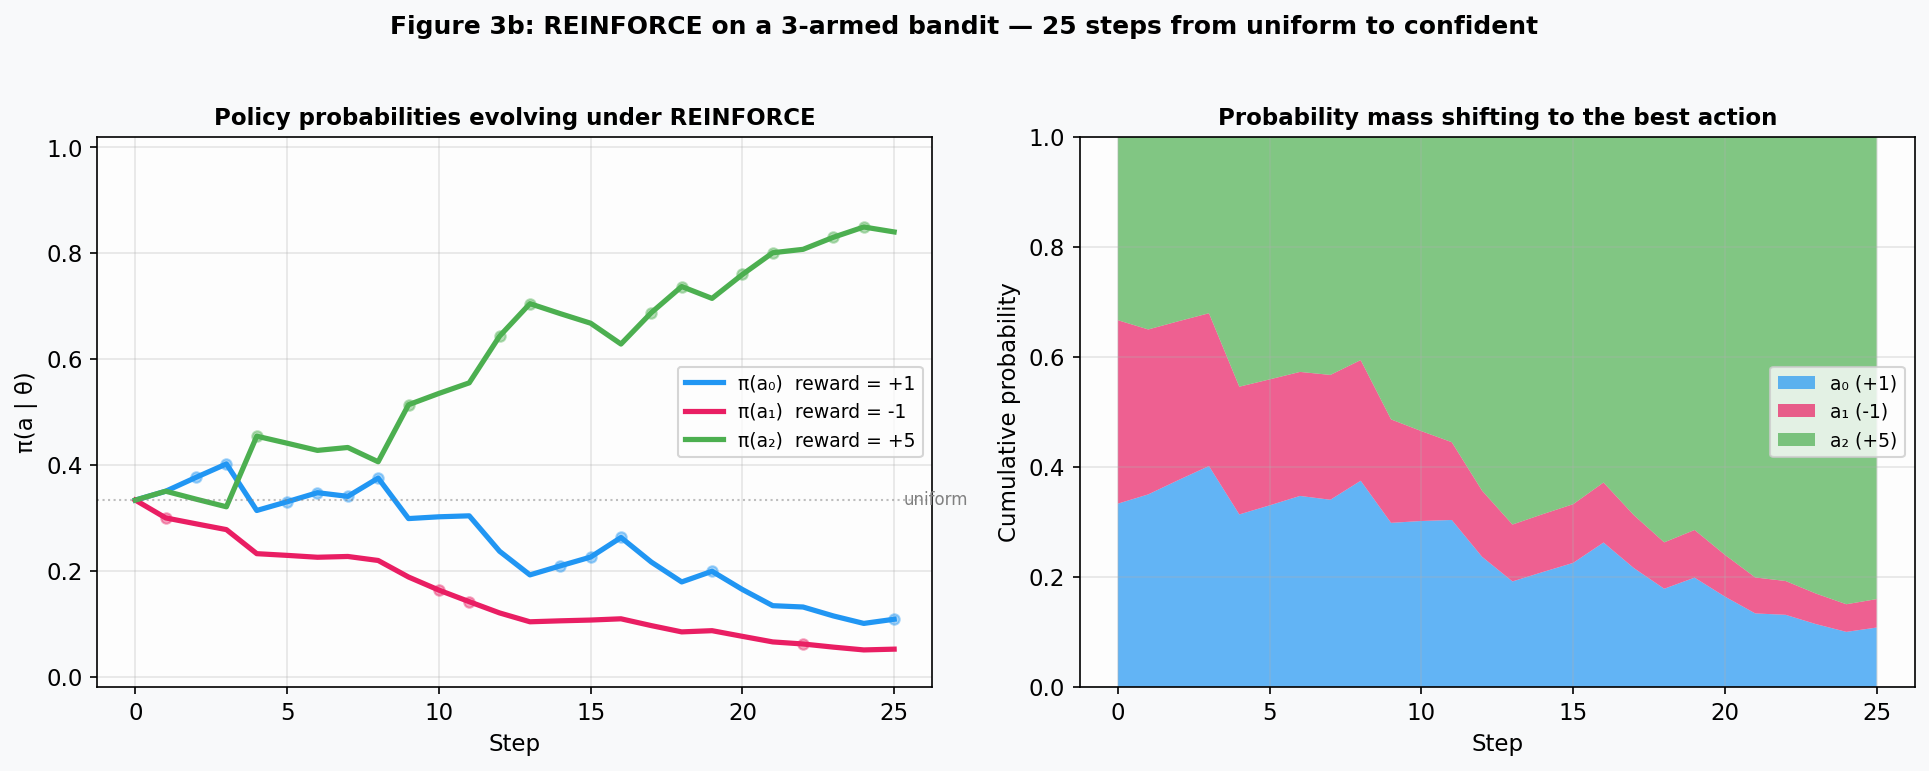

<!-- TAG: obs-bandit -->
> **What just happened, mechanically.** Each step: (1) sample an action from π, (2) observe the reward, (3) compute the score function ∇log π, (4) multiply by the reward, (5) step θ in that direction. When action 2 returns +5, its weight goes up. When action 1 returns -1, the negative reward flips the gradient and its weight goes down.
>
> This is REINFORCE on the simplest problem that exists. The lab asks you to scale it to a real environment with a neural network. The principle is identical — the network replaces our raw θ vector with something that can condition on state.

<!-- TAG: 3c-nn-policy -->
### 3.3  What Happens Inside a Neural Network Policy

Up to this point, our policy has been a single θ vector — three numbers, one per action. That worked for the bandit because the bandit has no state. The agent doesn't observe anything; it just picks an arm. But most RL problems aren't like that. A balancing robot observes four things every timestep — its position, its velocity, the angle of the pole, and how fast the pole is rotating. A maze agent observes its row and column. The policy needs to look at *what the agent currently sees* and then decide which action to favor. A flat θ vector can't do that — it has no inputs. A function can.

A neural network is that function. It takes in a state — a vector of numbers describing what the agent currently observes — and outputs a preference score for each possible action. Those output scores are called **logits**: raw, unnormalized numbers that can be any real value (positive, negative, huge, tiny). The name comes from the logistic function (softmax's two-action cousin), and it stuck. Softmax then converts the logits into valid probabilities, exactly the same way it converted our raw θ values earlier.

To make this concrete, imagine a simple robot environment where the agent observes 4 numbers (position, velocity, tilt angle, rotation speed) and can choose among 3 actions (push left, do nothing, push right). Here's the architecture we'll build below, spelled out in plain terms:

- **Input layer (4 neurons):** One input per state dimension — the four things the robot observes. Each observation gets its own entry point into the network.
- **Hidden layer (8 neurons):** This is where the network finds patterns. Each hidden neuron takes a weighted combination of all four inputs and passes it through a nonlinear activation function called ReLU (rectified linear unit — it just replaces negative values with zero). These eight neurons learn to detect features in the state that matter for choosing actions. Before training, the weights are random, so the features are meaningless. After training, they represent useful patterns the agent discovered.
- **Output layer (3 neurons):** One output per possible action (left, nothing, right). Each output is a logit — a raw score reflecting how much the network currently favors that action given this state. Softmax converts these three logits into three probabilities that sum to one.

The **forward pass** is what happens when a state goes into the network and action probabilities come out the other end: state → weighted sums → ReLU → weighted sums → logits → softmax → π(a|s). Every operation is differentiable, which means PyTorch can run the chain rule backward through all those layers to compute ∇_θ log π(a|s;θ) — the exact quantity REINFORCE needs.

Let's build this network and trace every step, not to train it (that's your lab), but to see that the gradient computation we did by hand is exactly what `.backward()` does automatically.

In [ ]:
# TAG: demo-nn-policy-internals
# Build a tiny policy network and trace every step of the forward pass.
# Goal: see that the neural network is just a fancier version of our θ → softmax pipeline.
#
# We're leaving the bandit behind. The bandit had no state — the agent just
# picked an arm. Now imagine a robot that observes 4 things about the world
# (position, velocity, tilt, spin) and chooses among 3 actions (left, nothing, right).
# The network takes those 4 observations as input and outputs 3 action scores.

torch.manual_seed(42)

# ── Step 1: Define the network ──────────────────────────────────────
# 4 inputs  = the 4 things the robot observes each timestep
# 8 hidden  = learned feature detectors (patterns in the state)
# 3 outputs = one logit (raw score) per action

class TinyPolicy(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(4, 8)   # fc = "fully connected": every input connects to every hidden neuron
        self.fc2 = nn.Linear(8, 3)   # second fully connected layer: every hidden neuron connects to every output

    def forward(self, state):
        x = torch.relu(self.fc1(state))  # hidden layer + ReLU activation
        logits = self.fc2(x)              # output layer (raw action scores)
        return logits

policy_net = TinyPolicy()

# ── Step 2: Count the learnable parameters ──────────────────────────
# Every connection between neurons has a weight. Every neuron has a bias.
# These are the θ values that REINFORCE will adjust.
print("Network structure:")
print(f"  Input  → Hidden:  4×8 weights + 8 biases = {4*8 + 8} parameters")
print(f"  Hidden → Output:  8×3 weights + 3 biases = {8*3 + 3} parameters")
total = sum(p.numel() for p in policy_net.parameters())
print(f"  Total learnable parameters: {total}")
print(f"  (Compare: our bandit had 3 parameters — one θ per action)\n")

# ── Step 3: Forward pass — state in, probabilities out ──────────────
# Imagine the robot just observed: position=0.5, velocity=-0.3, tilt=1.2, spin=0.0
state = torch.tensor([0.5, -0.3, 1.2, 0.0])
print("Forward pass (what happens when the agent sees a state):")
print(f"  State vector:  {state.numpy()}")
print(f"  (position=0.5, velocity=-0.3, tilt=1.2, spin=0.0)\n")

# Layer 1: multiply state by weights, add biases, apply ReLU
hidden = torch.relu(policy_net.fc1(state))
print(f"  Hidden layer:  {hidden.detach().numpy().round(4)}")
print(f"  (8 numbers = 8 learned features extracted from the state)")
print(f"  (ReLU zeroed out any negative values — that's the nonlinearity)\n")

# Layer 2: multiply hidden features by weights, add biases → logits
logits = policy_net.fc2(hidden)
print(f"  Logits:        {logits.detach().numpy().round(4)}")
print(f"  (3 numbers = one raw score per action, before softmax)\n")

# Softmax: convert logits to probabilities (same operation as Section 2)
probs = torch.softmax(logits, dim=-1)
print(f"  Probabilities: {probs.detach().numpy().round(4)}")
print(f"  (softmax turns logits into a valid probability distribution)\n")

# ── Step 4: Sample an action ────────────────────────────────────────
# The agent picks an action by sampling from these probabilities.
# Higher probability = more likely to be chosen, but it's stochastic.
dist = torch.distributions.Categorical(probs=probs)
action = dist.sample()
log_prob = dist.log_prob(action)

print(f"  Sampled action: {action.item()}")
print(f"  log π(a={action.item()}|s;θ) = {log_prob.item():.4f}")
print(f"  (this is the log-probability that REINFORCE needs)\n")

# ── Step 5: Compute the policy gradient ─────────────────────────────
# Suppose this action led to a return of G = +3.0.
# REINFORCE says: adjust θ to increase log π(a|s) in proportion to G.
# In code: define loss = -log_prob * G (negative because PyTorch minimizes).
G = 3.0
loss = -log_prob * G

# .backward() runs the chain rule through every layer, computing
# ∂loss/∂w for every weight and bias in the network.
loss.backward()

print("After .backward() — gradients on every parameter:")
for name, param in policy_net.named_parameters():
    grad_norm = param.grad.norm().item()
    print(f"  {name:12s}  shape={str(list(param.shape)):12s}  |grad| = {grad_norm:.4f}")

print(f"\nEvery parameter got a gradient. An optimizer.step() would nudge all")
print(f"{total} parameters to make action {action.item()} more likely next time")
print(f"(because G = +3.0 was positive). Negative G would push the other way.")
print(f"\nThis is exactly the score-function gradient from Section 3.1,")
print(f"computed automatically through all the layers via the chain rule.")

<!-- TAG: obs-nn-internals -->
> **The neural network is not magic.** In Section 2, we had three raw numbers (θ) and softmax turned them into action probabilities. Here, we have two layers of weights and biases that *compute* those raw numbers from the state — but the final step is still softmax, and the gradient computation is still the score function. The only difference is that `.backward()` has to chain through more layers to reach all the parameters. That's it. The neural network is a θ vector with a learned feature extractor bolted onto the front.

<!-- TAG: 4-variance-problem -->
---
## 4  The Variance Problem (and How Baselines Fix It)

REINFORCE is correct. The expected gradient points uphill. That's the theory. In practice, you also need the gradient estimate to not be garbage on any individual episode.

The problem is variance. Each episode gives one noisy sample of the gradient. The reward G varies wildly depending on which actions got sampled. The signal is buried in noise. Let's see exactly how bad this is, then fix it.

In [ ]:
# TAG: demo-variance-problem
# Same bandit as before. Collect 500 independent single-episode gradient estimates.
# See how much they scatter.

true_rewards = np.array([1.0, -1.0, 5.0])
theta = np.array([0.5, -0.2, 0.8])  # partially trained
probs = softmax(theta)

print(f"Current policy: π = [{probs[0]:.3f}, {probs[1]:.3f}, {probs[2]:.3f}]")
print(f"Expected reward: {(probs * true_rewards).sum():.3f}\n")

# 500 single-sample gradient estimates (NO baseline)
rng = np.random.RandomState(42)
n_samples = 500
gradients_raw = np.zeros((n_samples, 3))

for i in range(n_samples):
    action = rng.choice(3, p=probs)
    reward = true_rewards[action] + rng.randn() * 0.5
    score = -probs.copy()
    score[action] += 1.0
    gradients_raw[i] = score * reward

# Focus on θ₂ (the best action's weight)
g2 = gradients_raw[:, 2]

print(f"500 gradient estimates for θ₂ (best action's weight):")
print(f"  Mean:     {g2.mean():+.4f}  ← true gradient direction")
print(f"  Std:      {g2.std():.4f}")
print(f"  Min/Max:  {g2.min():+.4f} / {g2.max():+.4f}")
print(f"  Noise/signal ratio: {g2.std() / abs(g2.mean()):.1f}x")
wrong_sign = (g2 < 0).sum() if g2.mean() > 0 else (g2 > 0).sum()
print(f"  Wrong-direction estimates: {wrong_sign}/{n_samples} ({wrong_sign/n_samples*100:.0f}%)")
print(f"\n  The noise is {g2.std() / abs(g2.mean()):.0f}x larger than the signal.")
print("  Any single estimate has a decent chance of pointing the wrong way.")

<!-- TAG: 4b-baseline-explanation -->
### 4.1  The Fix: Subtract a Baseline

The gradient estimate from Section 3.2 was ∇_θ log π(a|s;θ) · G_t. The return G_t is the problem — it can be any positive or negative number, and its magnitude swamps the useful directional signal. The fix is to subtract a **baseline** b(s) before multiplying:

∇_θ log π(a|s;θ) · (G_t − b)

So what is b? It's your answer to the question: "how much reward do I *usually* get from this state?" The baseline (b) is an estimate of the expected return — the average outcome you'd see if you ran many episodes from the same state. In practice, the most common choice is the state-value function: b(s) = V^π(s). You can learn V alongside the policy (that's what Actor-Critic does in Section 5), or in simpler settings you can use a running average of observed rewards.

The quantity (G_t − b) is called the **advantage**. It answers: "was this action better or worse than what I typically get?" If the agent earned G_t = +5 and the baseline says this state usually yields +4, the advantage is +1 — this action was slightly better than average, so nudge the policy toward it. If another action earned +5 but the baseline for that state is +6, the advantage is −1 — worse than average, nudge away. Same raw return, opposite signals. That's a much sharper indicator of action quality than the raw number alone.

Why doesn't subtracting b change the expected gradient? Because ∇_θ log π, summed over all actions weighted by π, is zero. Any baseline that doesn't depend on the action gets multiplied by that zero in expectation. So b vanishes from the expected gradient — but it doesn't vanish from the *variance*. Centering the signal around zero means the gradient estimates swing less wildly from episode to episode.

Same 500 episodes as above, same random seed, but now we subtract b = E[R] from each reward before computing the gradient:

In [ ]:
# TAG: demo-baseline-fix
# Same 500 episodes, now subtract a baseline.
# Variance drops. Mean stays the same. That's the whole trick.

baseline = (probs * true_rewards).sum()  # E[R] under current policy
print(f"Baseline b = E[R] = {baseline:.3f}\n")

rng = np.random.RandomState(42)  # same seed → same actions and rewards
gradients_bl = np.zeros((n_samples, 3))

for i in range(n_samples):
    action = rng.choice(3, p=probs)
    reward = true_rewards[action] + rng.randn() * 0.5
    score = -probs.copy()
    score[action] += 1.0
    advantage = reward - baseline
    gradients_bl[i] = score * advantage

g2_bl = gradients_bl[:, 2]

print(f"Same 500 episodes WITH baseline subtraction:")
print(f"  Mean:     {g2_bl.mean():+.4f}  ← same direction (unbiased!)")
print(f"  Std:      {g2_bl.std():.4f}")
print(f"  Noise/signal: {g2_bl.std() / abs(g2_bl.mean()):.1f}x")
wrong_sign_bl = (g2_bl < 0).sum() if g2_bl.mean() > 0 else (g2_bl > 0).sum()
print(f"  Wrong-direction: {wrong_sign_bl}/{n_samples} ({wrong_sign_bl/n_samples*100:.0f}%)")

var_reduction = (g2.var() - g2_bl.var()) / g2.var() * 100
print(f"\nVariance reduction: {var_reduction:.0f}%")
print(f"  Raw variance:      {g2.var():.6f}")
print(f"  Baseline variance: {g2_bl.var():.6f}\n")

# Verify unbiasedness: E[∇log π · b] should ≈ 0
rng2 = np.random.RandomState(123)
bias_check = np.zeros((10000, 3))
for i in range(10000):
    action = rng2.choice(3, p=probs)
    score = -probs.copy()
    score[action] += 1.0
    bias_check[i] = score * baseline

print("Is the baseline biased?")
print(f"  E[∇log π · b] ≈ {bias_check.mean(axis=0).round(6)}")
print("  (Should be ≈ [0, 0, 0]. It is. Subtracting a state-dependent")
print("  baseline never changes the expected gradient — only the variance.)")

<!-- TAG: viz-variance-reduction -->
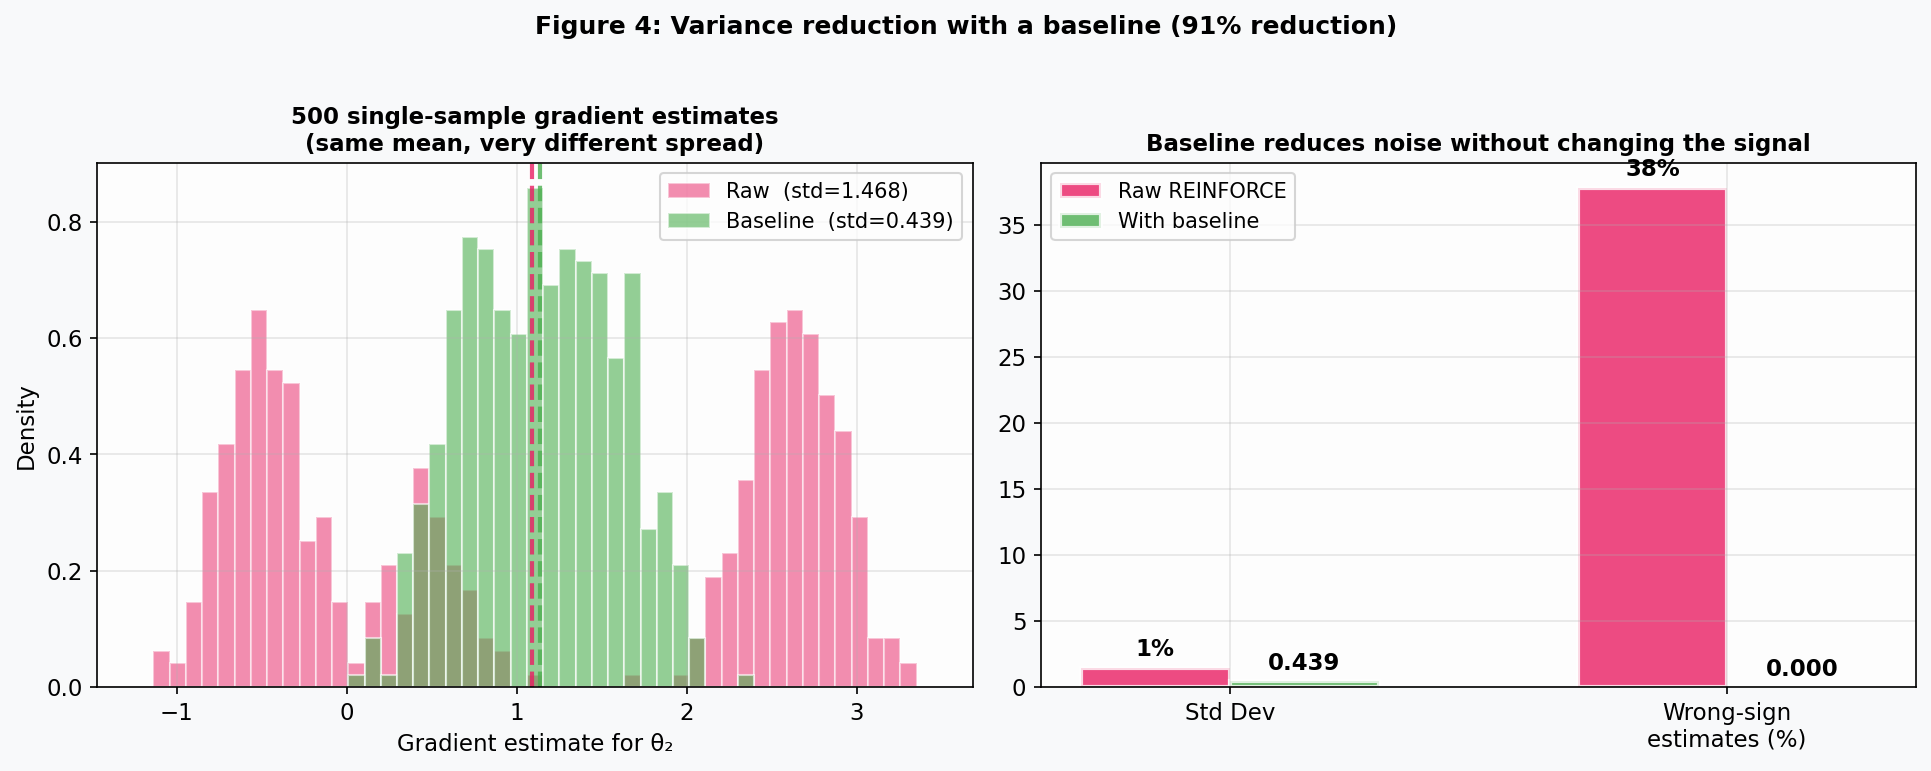

<!-- TAG: obs-variance -->
> **This is the most important practical trick in policy gradients.** Same expected gradient, dramatically less noise. The lab asks you to implement REINFORCE with and without a baseline and plot the learning curves. Those curves are the visual version of what these numbers just showed: same destination, far less wandering.
>
> The optimal baseline is V^π(s) — the expected return from each state. Subtracting it gives the **advantage** A(s,a) = G_t - V(s): was this action better or worse than what I'd expect on average from this state? That's a sharper signal than raw return, and it's the bridge to Actor-Critic methods.

<!-- TAG: 5-actor-critic -->
---
## 5  From Episodes to Steps: Actor-Critic

REINFORCE waits until the end of an episode to learn anything. If the agent takes a terrible action at step 3 and the episode runs for 200 more steps, all that mid-episode information sits unused until the episode ends. Then it arrives as a single, noisy gradient.

Actor-Critic methods fix this by updating **every step**. The key move: replace the Monte Carlo return $G_t$ with a one-step TD estimate:

$$\delta_t = R_{t+1} + \gamma V(S_{t+1}; w) - V(S_t; w)$$

This TD error $\delta$ is an advantage estimate. If $\delta > 0$, the action produced a better outcome than the critic expected — reinforce it. If $\delta < 0$, it was worse — discourage it.

The name tells you the architecture:
- **Actor**: the policy π(a|s;θ). Decides what to do.
- **Critic**: the value function V(s;w). Judges how good the actor's decisions are.

The tradeoff: we've introduced **bias** (because V is an estimate, not the true value), but we've reduced **variance** (because one-step TD targets are much less noisy than full-episode returns). In practice, the variance reduction usually wins.

### 5.1  Watching Actor-Critic Learn a Chain

We need an environment simple enough to see what the actor and critic are actually learning. Here's the setup: a chain of 7 states, numbered 0 through 6. The agent starts in the middle (state 3). At each step it can go left or right. The episode ends when the agent reaches either edge. The only reward is +1 for reaching the right end (state 6); reaching the left end gives 0. Everything else gives 0.

This means the optimal policy is trivial: always go right. But the agent doesn't know that. It starts with a random policy and a random value function. The question is whether Actor-Critic can figure it out — and how fast, compared to waiting for whole episodes to finish.

The code below builds this chain, then runs Actor-Critic for 200 episodes. Watch for two things in the output: the success rate (fraction of episodes where the agent reaches the right end) in the first 20 episodes vs. the last 20, and how quickly the agent crosses the 80% threshold. That speed is the payoff of updating every step instead of every episode.

<!-- TAG: viz-chain-mdp -->
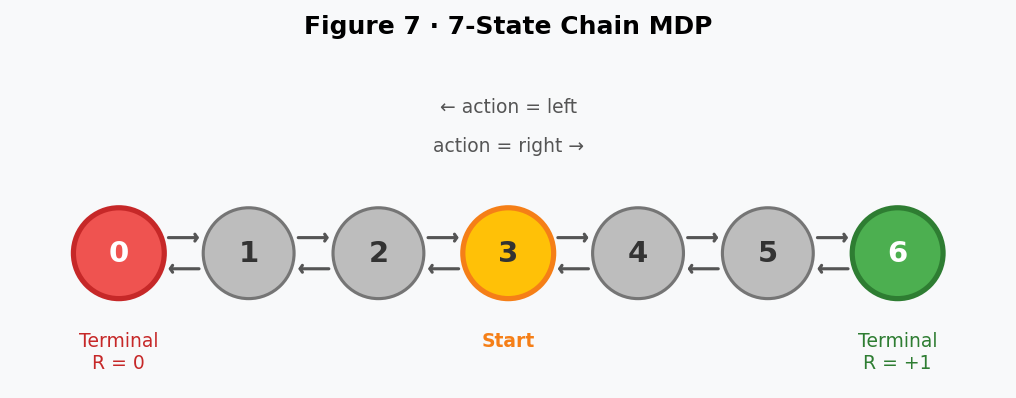

<!-- TAG: viz-actor-critic -->
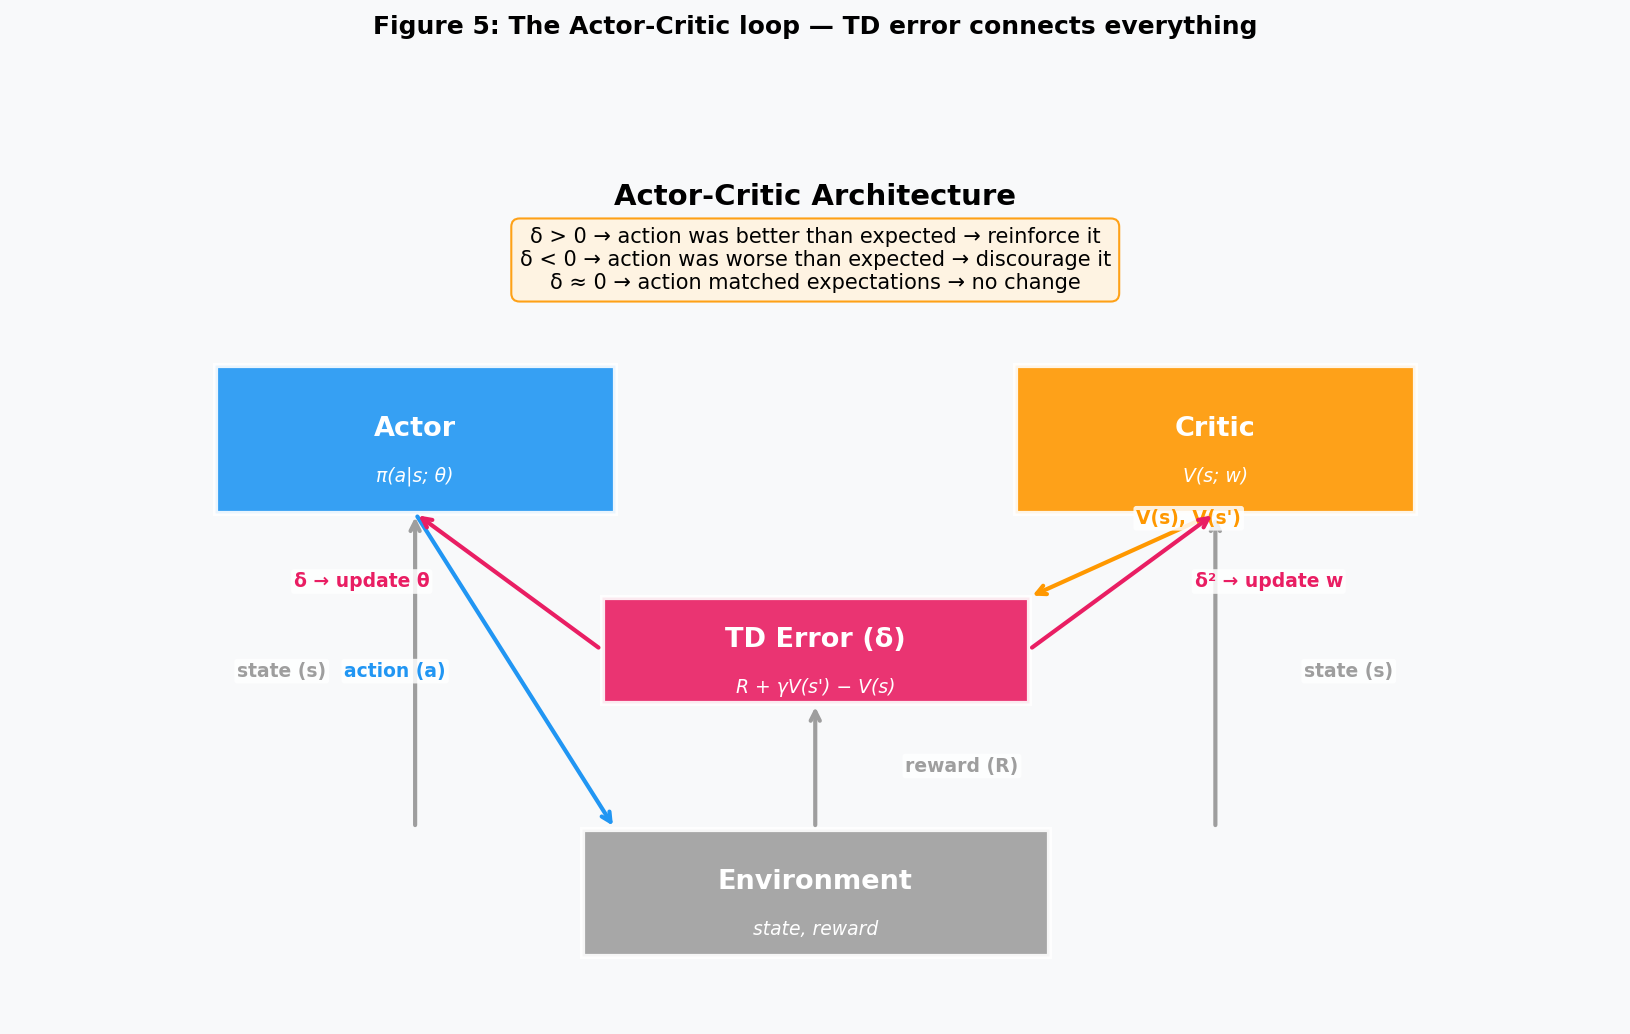

In [ ]:
# TAG: demo-chain-mdp
# A 7-state chain MDP. Start in state 3. Go left or right.
# Reward: +1 at right end (state 6), 0 elsewhere. Episode ends at edges.
# Small enough to inspect every learned value.

class ChainMDP:
    def __init__(self, n_states=7):
        self.n_states = n_states
        self.start = n_states // 2
        self.state = self.start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        self.state += (1 if action == 1 else -1)
        done = (self.state <= 0 or self.state >= self.n_states - 1)
        reward = 1.0 if self.state >= self.n_states - 1 else 0.0
        self.state = max(0, min(self.n_states - 1, self.state))
        return self.state, reward, done


def one_hot(state, n=7):
    x = torch.zeros(n)
    x[state] = 1.0
    return x


# ── Run Actor-Critic on the chain ────────────────────────────────────
torch.manual_seed(0)
np.random.seed(0)

actor  = nn.Sequential(nn.Linear(7, 32), nn.ReLU(), nn.Linear(32, 2))
critic = nn.Sequential(nn.Linear(7, 32), nn.ReLU(), nn.Linear(32, 1))
actor_opt  = optim.Adam(actor.parameters(),  lr=0.01)
critic_opt = optim.Adam(critic.parameters(), lr=0.02)

env = ChainMDP()
gamma = 0.99
episode_rewards = []

for ep in range(200):
    state = env.reset()
    total_reward = 0

    for t in range(50):
        s = one_hot(state)
        logits = actor(s)
        dist = torch.distributions.Categorical(logits=logits)
        action = dist.sample()
        log_prob = dist.log_prob(action)
        value = critic(s).squeeze()

        next_state, reward, done = env.step(action.item())
        total_reward += reward

        # TD error (the one-step advantage)
        if done:
            td_target = torch.tensor(reward)
        else:
            td_target = reward + gamma * critic(one_hot(next_state)).squeeze().detach()
        td_error = td_target - value

        # Critic update: minimize TD error²
        critic_loss = td_error ** 2
        critic_opt.zero_grad()
        critic_loss.backward()
        critic_opt.step()

        # Actor update: ∇ log π · δ  (scale by advantage)
        actor_loss = -log_prob * td_error.detach()
        actor_opt.zero_grad()
        actor_loss.backward()
        actor_opt.step()

        state = next_state
        if done:
            break

    episode_rewards.append(total_reward)

# Report
window = 20
smoothed = [np.mean(episode_rewards[max(0,i-window):i+1]) for i in range(len(episode_rewards))]
first_20 = np.mean(episode_rewards[:20])
last_20 = np.mean(episode_rewards[-20:])
first_solve = next((i for i in range(window, len(smoothed)) if smoothed[i] >= 0.8), None)

print("Actor-Critic on 7-State Chain (200 episodes)")
print("=" * 50)
print(f"  Success rate, first 20 eps:  {first_20:.0%}")
print(f"  Success rate, last 20 eps:   {last_20:.0%}")
if first_solve:
    print(f"  First 80%+ success (20-ep window): episode {first_solve}")
print()

# Let the actual numbers drive the narrative
if first_20 >= 0.8:
    print(f"Look at the first 20 episodes: {first_20:.0%} success already.")
    print("A random policy on this chain would succeed ~50% of the time")
    print("(random walk from state 3 hits either end with equal probability).")
    print(f"But Actor-Critic updates at EVERY step, not once per episode.")
    print("By the time episode 1 finishes, the network has already been")
    print("updated 3-6 times. By episode 20, the policy is nearly optimal.")
    print("That's the whole point of per-step updates.")
elif first_20 >= 0.5:
    print(f"First 20 episodes: {first_20:.0%} — close to the ~50% you'd expect")
    print("from a random walk on this chain. The agent is still learning.")
    if last_20 > 0.8:
        print(f"By the end: {last_20:.0%}. It figured out to go right.")
else:
    print(f"First 20 episodes: {first_20:.0%} — still exploring.")
    if last_20 > 0.8:
        print(f"By the end: {last_20:.0%}. It learned the optimal policy.")

if last_20 > 0.8:
    print(f"\nThe critic learned that states closer to the right edge are more")
    print("valuable. The actor learned to pick the action that moves toward")
    print("higher-valued states. Section 5.2 lets you look inside both.")

<!-- TAG: obs-ac-learning -->
> Actor-Critic learns fast on this chain because it doesn't have to wait for episodes to end. Every step, the critic says "here's how good I think this state is," the TD error says "that action was better/worse than expected," and the actor adjusts immediately. By the time the episode finishes, the actor has already been updated 3–6 times.

<!-- TAG: 5b-inspect-values -->
### 5.2  Reading the Critic's Mind

After training, the critic has learned V(s) for every state. The actor has learned a policy. Let's inspect both — this is the kind of interpretability you rarely get in deep RL, and the chain is small enough to see everything.

In [ ]:
# TAG: demo-inspect-ac
# What did the actor and critic learn?

print("Learned V(s) — the critic's value estimates")
print("=" * 50)
print(f"  {'State':>5}  {'V(s)':>8}  {'Interpretation'}")
print("  " + "-" * 48)
for s in range(7):
    v = critic(one_hot(s)).item()
    if s == 0:
        interp = "Left edge (dead end, no reward)"
    elif s == 6:
        interp = "Right edge (goal, reward = 1)"
    elif s == 3:
        interp = "Start state"
    else:
        interp = ""
    print(f"  {s:5d}  {v:8.3f}  {interp}")

print(f"\n  Values should increase left → right (closer to the +1 goal).")
print(f"  State 0 should be near 0 (dead end). State 5 should be high.\n")

print("Learned π(a|s) — the actor's policy")
print("=" * 50)
print(f"  {'State':>5}  {'π(left)':>8}  {'π(right)':>9}  {'Preferred':>10}")
print("  " + "-" * 40)
for s in range(1, 6):
    with torch.no_grad():
        logits = actor(one_hot(s))
        p = torch.softmax(logits, dim=-1).numpy()
    preferred = "← left" if p[0] > p[1] else "right →"
    print(f"  {s:5d}  {p[0]:8.3f}  {p[1]:9.3f}  {preferred:>10}")

print(f"\n  The agent should go right from every state (toward the goal).")
print(f"  That's the optimal policy for this chain.")

<!-- TAG: 5b2-td-error-intro -->
Section 5 introduced the TD error formula: δ_t = R + γV(s') − V(s). We said this is the signal that teaches the actor — positive δ means "better than expected," negative means "worse." But what does that actually look like during a real episode?

The table below runs the trained agent through one episode on the chain and prints δ at every step. Watch for two things: (1) δ should be close to zero for most steps, because a well-trained critic predicts accurately, and (2) the biggest δ should appear at the transition where the agent reaches the goal — that's where the actual reward shows up, which is the one thing the critic can't perfectly anticipate on the first visit.

In [ ]:
# TAG: demo-td-error-trace
# Show what the TD error looks like during a single episode.
# This is the signal that teaches the actor.

print("TD errors during one episode (trained agent)")
print("=" * 60)
hdr_target = "R + γV(s')"
print(f"  {'t':>2}  {'State':>5}  {'Action':>7}  {'V(s)':>7}  {hdr_target:>11}  {'δ':>7}")
print("  " + "-" * 50)

env = ChainMDP()
state = env.reset()
for t in range(10):
    s = one_hot(state)
    with torch.no_grad():
        logits = actor(s)
        p = torch.softmax(logits, dim=-1)
        v = critic(s).item()
    action = torch.distributions.Categorical(probs=p).sample().item()
    next_state, reward, done = env.step(action)

    if done:
        td_target = reward
    else:
        td_target = reward + gamma * critic(one_hot(next_state)).item()
    td_error = td_target - v

    act_str = "right →" if action == 1 else "← left"
    print(f"  {t:2d}  {state:5d}  {act_str:>7}  {v:7.3f}  {td_target:11.3f}  {td_error:+7.3f}")

    state = next_state
    if done:
        print(f"  {'':2}  {state:5d}  {'DONE':>7}  (reached {'goal' if reward > 0 else 'dead end'})")
        break

print(f"\n  δ ≈ 0 means the critic predicted correctly — no surprise.")
print(f"  δ > 0 means the outcome was BETTER than expected → reinforce the action.")
print(f"  δ < 0 means WORSE than expected → discourage the action.")
print(f"  This signal is available at EVERY step, not just episode end.")

<!-- TAG: obs-td-error -->
> **The TD error is the Actor-Critic's entire teaching signal.** At every step, the critic asks: "how good is where I ended up, compared to where I was?" If the answer is "better than expected," the actor gets positive reinforcement. If worse, negative. That's the same logic as the advantage A(s,a) = Q(s,a) - V(s), approximated with a single transition. Biased (because V is learned, not exact), but available immediately — no waiting for the episode to finish.

<!-- TAG: 5c-comparison -->
### 5.3  REINFORCE vs. Actor-Critic — Head to Head

We've claimed Actor-Critic learns faster because it updates every step instead of once per episode. Let's find out if that's actually true on our chain.

The code below runs both algorithms on a 13-state chain (start in state 6, goal at state 12 — at least 6 correct steps needed), same network size, same learning rate, 5 random seeds each. Before you look at the output, make a prediction: which method wins, and by how much?

In [35]:
# TAG: demo-reinforce-vs-ac
# Run both algorithms on a 13-state chain where the difference is visible.
# The 7-state chain was too easy — both solve it instantly.
# A 21+ state chain is too hard for the critic (bootstrapping bias dominates).
# 13 states is the sweet spot: 6 correct steps needed, long enough for the
# per-step update advantage to show, short enough for the critic to learn.

N_COMPARE = 13  # 13-state chain: start=6, goal=12

def one_hot_n(state, n):
    x = torch.zeros(n)
    x[state] = 1.0
    return x

def run_reinforce(n_states, n_episodes=300, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    policy = nn.Sequential(nn.Linear(n_states, 32), nn.ReLU(), nn.Linear(32, 2))
    opt = optim.Adam(policy.parameters(), lr=0.01)
    env = ChainMDP(n_states)
    returns = []

    for ep in range(n_episodes):
        state = env.reset()
        log_probs, rewards = [], []
        for _ in range(100):
            s = one_hot_n(state, n_states)
            logits = policy(s)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            log_probs.append(dist.log_prob(action))
            state, reward, done = env.step(action.item())
            rewards.append(reward)
            if done:
                break

        G = 0
        disc_returns = []
        for r in reversed(rewards):
            G = r + 0.99 * G
            disc_returns.insert(0, G)

        loss = sum(-lp * g for lp, g in zip(log_probs, disc_returns))
        opt.zero_grad()
        loss.backward()
        opt.step()
        returns.append(sum(rewards))
    return returns


def run_actor_critic(n_states, n_episodes=300, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)
    actor  = nn.Sequential(nn.Linear(n_states, 32), nn.ReLU(), nn.Linear(32, 2))
    critic = nn.Sequential(nn.Linear(n_states, 32), nn.ReLU(), nn.Linear(32, 1))
    a_opt = optim.Adam(actor.parameters(),  lr=0.01)
    c_opt = optim.Adam(critic.parameters(), lr=0.02)
    env = ChainMDP(n_states)
    returns = []

    for ep in range(n_episodes):
        state = env.reset()
        total_reward = 0
        for _ in range(100):
            s = one_hot_n(state, n_states)
            logits = actor(s)
            dist = torch.distributions.Categorical(logits=logits)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            value = critic(s).squeeze()

            next_state, reward, done = env.step(action.item())
            total_reward += reward

            td_target = torch.tensor(reward) if done else reward + 0.99 * critic(one_hot_n(next_state, n_states)).squeeze().detach()
            td_error = td_target - value

            c_loss = td_error ** 2
            c_opt.zero_grad(); c_loss.backward(); c_opt.step()

            a_loss = -log_prob * td_error.detach()
            a_opt.zero_grad(); a_loss.backward(); a_opt.step()

            state = next_state
            if done:
                break
        returns.append(total_reward)
    return returns


# Run 5 seeds each
print(f"REINFORCE vs. Actor-Critic on {N_COMPARE}-State Chain (5 seeds, 300 episodes)")
print("=" * 65)
print(f"  Agent starts in state {N_COMPARE // 2}, must reach state {N_COMPARE - 1} for reward.")
print(f"  That's {N_COMPARE // 2} correct steps minimum — long enough to see a difference.\n")

rf_runs, ac_runs = [], []
for seed in range(5):
    rf_runs.append(run_reinforce(N_COMPARE, n_episodes=300, seed=seed))
    ac_runs.append(run_actor_critic(N_COMPARE, n_episodes=300, seed=seed))

rf_runs = np.array(rf_runs)
ac_runs = np.array(ac_runs)

window = 20
for name, runs in [("REINFORCE", rf_runs), ("Actor-Critic", ac_runs)]:
    mean_run = runs.mean(axis=0)
    smooth = [np.mean(mean_run[max(0,i-window):i+1]) for i in range(len(mean_run))]
    first_80 = next((i for i in range(window, len(smooth)) if smooth[i] >= 0.8), None)
    first_50 = next((i for i in range(window, len(smooth)) if smooth[i] >= 0.5), None)
    last_20 = mean_run[-20:].mean()
    print(f"  {name}:")
    print(f"    Success rate (last 20 eps):  {last_20:.0%}")
    print(f"    First 50%+ (20-ep window):   {f'episode {first_50}' if first_50 else 'not reached'}")
    print(f"    First 80%+ (20-ep window):   {f'episode {first_80}' if first_80 else 'not reached'}")
    print()

rf_last = rf_runs[:, -20:].mean()
ac_last = ac_runs[:, -20:].mean()

print("The bias-variance tradeoff in action:")
print("-" * 40)
if rf_last >= ac_last:
    print("REINFORCE holds its own (or wins) on this chain. That might be")
    print("surprising — didn't we say per-step updates are better?")
else:
    print("Actor-Critic edges ahead here — per-step updates help.")
print()
print("The chain has short episodes and only a terminal reward. REINFORCE")
print("gets a clean, unbiased signal: the episode either succeeded or it")
print("didn't. Actor-Critic updates every step, but those updates depend")
print("on V(s) estimates that start out random. Early on, the critic is")
print("guessing, and bad guesses propagate through the TD error. That's")
print("bootstrapping bias — the cost of not waiting for the true return.")
print()
print("Actor-Critic's advantage grows with episode length and reward")
print("complexity. On a 500-step game with dense rewards, waiting until")
print("the end to learn (REINFORCE) would be painfully slow. On a short")
print("chain with binary outcomes, the bias cost can outweigh the speed")
print("benefit. Neither method dominates everywhere — that's why both exist.")

REINFORCE vs. Actor-Critic on 13-State Chain (5 seeds, 300 episodes)
  Agent starts in state 6, must reach state 12 for reward.
  That's 6 correct steps minimum — long enough to see a difference.

  REINFORCE:
    Success rate (last 20 eps):  100%
    First 50%+ (20-ep window):   episode 20
    First 80%+ (20-ep window):   episode 20

  Actor-Critic:
    Success rate (last 20 eps):  80%
    First 50%+ (20-ep window):   episode 20
    First 80%+ (20-ep window):   episode 26

The bias-variance tradeoff in action:
----------------------------------------
REINFORCE holds its own (or wins) on this chain. That might be
surprising — didn't we say per-step updates are better?

The chain has short episodes and only a terminal reward. REINFORCE
gets a clean, unbiased signal: the episode either succeeded or it
didn't. Actor-Critic updates every step, but those updates depend
on V(s) estimates that start out random. Early on, the critic is
guessing, and bad guesses propagate through the TD error. 

<!-- TAG: 5d-method-summary -->
### 5.4  The Policy Gradient Family at a Glance

| Method | Updates when? | Advantage estimate | Bias | Variance | When to use |
|---|---|---|---|---|---|
| **REINFORCE** | Episode end | $G_t$ (full return) | None | High | Simple problems, baselines |
| **REINFORCE + baseline** | Episode end | $G_t - V(s)$ | None | Medium | Standard starting point |
| **Actor-Critic (1-step)** | Every step | $\delta_t = R + \gamma V(s') - V(s)$ | Yes (bootstrap) | Low | Online learning, longer episodes |
| **n-step Actor-Critic** | Every n steps | Multi-step TD target | Medium | Medium | Tunable bias-variance tradeoff |

The lab asks you to implement REINFORCE ± baseline (Part 1) and Actor-Critic (Part 2). You'll see these tradeoffs in your own learning curves.

<!-- TAG: 6-synthesis -->
---
## 6  The Thread Running Through All of It

Here's the connection that wasn't visible while we were in the details.

The entire course has been circling a single tension: **you can't act without knowing, and you can't know without acting.** Weeks 1 through 5 resolved this by learning values — estimates of long-run reward — and then extracting actions from those estimates via argmax. It works. It's often the best approach. But it has a structural limitation: the policy is always an afterthought, a greedy shadow of the value function, and it can only be deterministic.

This week we inverted the relationship. The policy became the primary object. The value function, when it appears at all, serves the policy — as a baseline to reduce variance (REINFORCE with baseline) or as a critic that evaluates the actor's decisions step by step (Actor-Critic). The policy is no longer derived from values. Values are derived for the policy.

That inversion is not just a technical trick. It's a philosophical shift in how the agent relates to its environment. A value-based agent asks "what will happen if I do each thing?" and picks the best prediction. A policy gradient agent asks "how should I adjust my tendency to do each thing, given what happened last time I tried?" The first approach requires a complete ranking of actions. The second only requires a direction of improvement.

Actor-Critic is the bridge between these worldviews. The critic carries forward everything we learned in Weeks 2–5 — Bellman equations, TD learning, function approximation. The actor carries this week's insight — parameterized policies, the score function, gradient ascent on expected return. Every modern deep RL algorithm that matters — PPO, SAC, TD3, the RLHF that fine-tunes large language models — descends from this marriage.

Next week we add the third piece: a learned model of the world, so the agent can plan and imagine rather than just react. That's the last structural idea in the course. After that, it's synthesis all the way down.

---

<!-- TAG: references -->
## References

1. **Sutton, R.S. & Barto, A.G. (2018).** *Reinforcement Learning: An Introduction* (2nd ed.). MIT Press. **Chapter 13: Policy Gradient Methods.** http://incompleteideas.net/book/the-book-2nd.html

2. **Williams, R.J. (1992).** Simple statistical gradient-following algorithms for connectionist reinforcement learning. *Machine Learning*, 8, 229–256. https://doi.org/10.1007/BF00992696

3. **Sutton, R.S., McAllester, D., Singh, S., & Mansour, Y. (2000).** Policy gradient methods for reinforcement learning with function approximation. *Advances in Neural Information Processing Systems (NeurIPS)*, 12. https://proceedings.neurips.cc/paper/1999/hash/464d828b85b0bed98e80ade0a5c43b0f-Abstract.html

4. **Schulman, J., Wolski, F., Dhariwal, P., Radford, A., & Klimov, O. (2017).** Proximal policy optimization algorithms. *arXiv preprint arXiv:1707.06347.* https://arxiv.org/abs/1707.06347

5. **Haarnoja, T., Zhou, A., Abbeel, P., & Levine, S. (2018).** Soft Actor-Critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor. *Proceedings of the 35th International Conference on Machine Learning (ICML).* https://proceedings.mlr.press/v80/haarnoja18b.html

---

### Key Concepts This Week

| Concept | One-Line Summary |
|---|---|
| Policy gradient motivation | Some problems need stochastic or continuous-action policies that argmax can't produce |
| Softmax policy | Converts real-valued weights to a probability distribution over discrete actions |
| Gaussian policy | Parameterizes continuous actions via learned mean μ and std σ |
| Policy gradient theorem | ∇J(θ) = E[∇log π(a|s;θ) · G_t] — weight the score function by the return |
| Score function trick | ∇log π = ∇π/π — converts probability gradients to something computable from samples |
| REINFORCE | Monte Carlo policy gradient: sample episode, compute returns, update at episode end |
| Variance problem | Raw REINFORCE gradients are very noisy — the signal can be smaller than the noise |
| Baseline | Subtract V(s) from G_t → advantage A(s,a). Reduces variance without introducing bias |
| Actor-Critic | Replace G_t with TD error δ = R + γV(s') - V(s). Updates every step, lower variance, some bias |
| The tradeoff | REINFORCE: unbiased, high variance, episodic. Actor-Critic: biased, low variance, online |

---

**Lab 6**: Implement REINFORCE ± baseline on CartPole (Part 1) or Actor-Critic on a continuous environment (Part 2). See the course D2L page for full instructions.